<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     1039

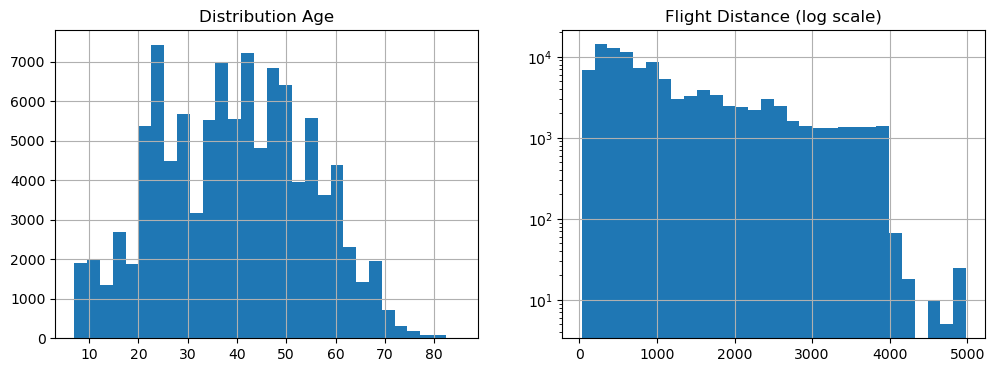

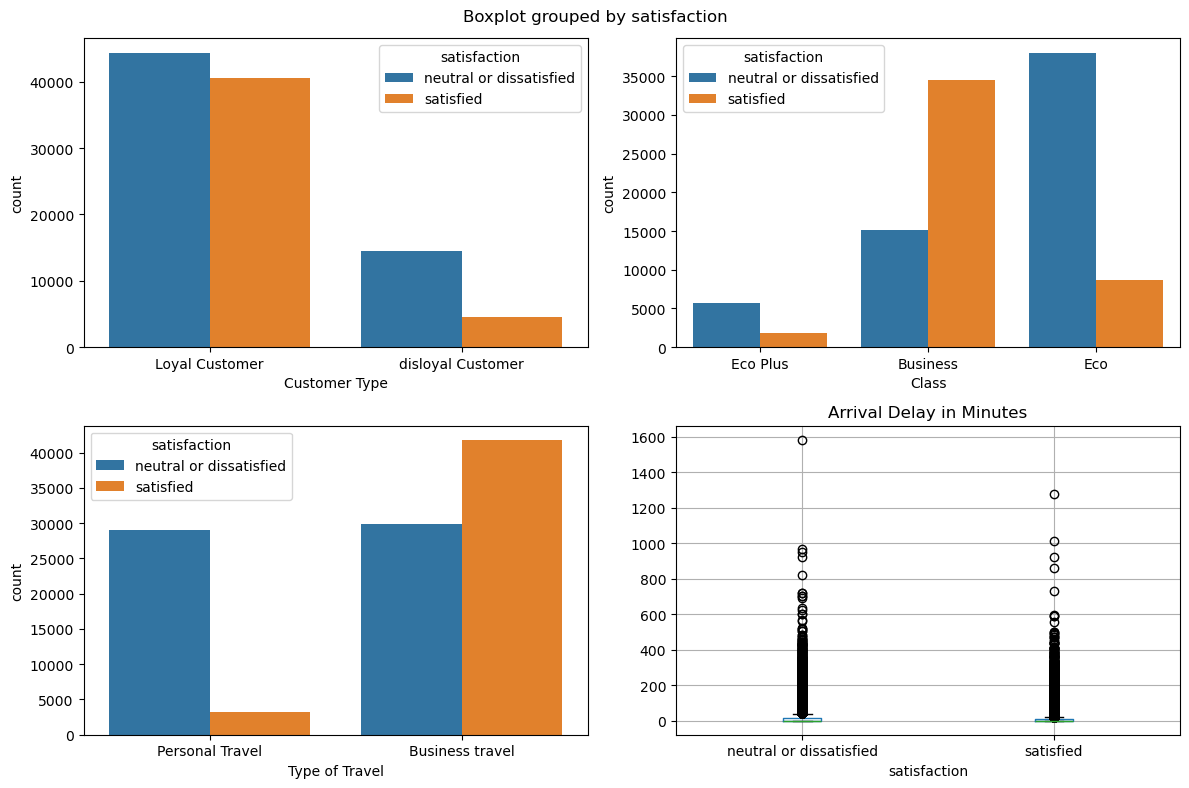

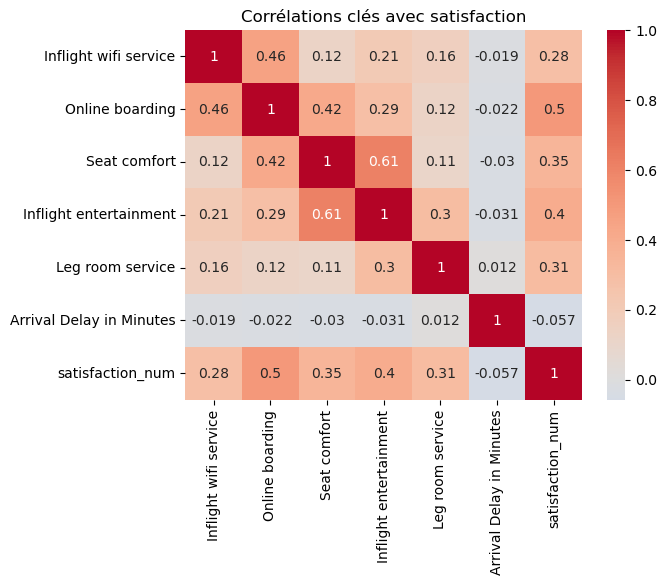

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement du dataset propre 
train = pd.read_csv('train_clean.csv')

# 2. Aperçu rapide
print(train.info())
print(train['satisfaction'].value_counts(normalize=True))

# 3. Distribution âge + distance (histogrammes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['Age'].hist(ax=axes[0], bins=30)
axes[0].set_title('Distribution Age')
train['Flight Distance'].hist(ax=axes[1], bins=30, log=True)
axes[1].set_title('Flight Distance (log scale)')
plt.savefig('age_distance.png')
plt.show()

# 4. Taux satisfaction par segments clés (barplots)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.countplot(data=train, x='Customer Type', hue='satisfaction', ax=axes[0,0])
sns.countplot(data=train, x='Class', hue='satisfaction', ax=axes[0,1])
sns.countplot(data=train, x='Type of Travel', hue='satisfaction', ax=axes[1,0])
train.boxplot(column='Arrival Delay in Minutes', by='satisfaction', ax=axes[1,1])
plt.tight_layout()
plt.savefig('segments_satisfaction.png')
plt.show()

# 5. Heatmap corrélation notes de service + satisfaction
# Creation de variable satisfaction_num
train['satisfaction_num'] = (train['satisfaction'] == 'satisfied').astype(int)

score_cols = ['Inflight wifi service', 'Online boarding', 'Seat comfort', 
              'Inflight entertainment', 'Leg room service', 'Arrival Delay in Minutes']

corr_matrix = train[score_cols + ['satisfaction_num']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations clés avec satisfaction')
plt.savefig('correlation_heatmap.png')
plt.show()